# Predicting Fasciolosis in Uruguayan Bovine Carcasses: An End-to-End Machine Learning Study

# Executive Summary
This study developed and evaluated a supervised machine learning model to predict fasciolosis (liver fluke infection) in bovine carcasses processed at a major Uruguayan abattoir in 2016. Using a reproducible pipeline encompassing data preparation, feature engineering, feature ranking, Bayesian hyperparameter optimization, and held-out testing, we identified carcass weight, dental age, and fat score as the most informative predictors of fasciolosis presence. A tuned LightGBM classifier achieved an AUC-ROC of 0.6519 and a recall of 0.7263 on the test set, indicating a sensitivity-oriented operating point appropriate for disease detection, albeit with a precision of 0.4451 and overall accuracy of 0.5822. These findings underscore the strong post-slaughter physiological signal of fasciolosis in carcass weight and support the deployment of threshold-tuned models for operational surveillance, while highlighting avenues for improving precision and generalizability.



# Introduction
Fasciolosis caused by liver flukes is a persistent health and economic burden in ruminant production systems. In abattoir settings, the accurate and timely identification of infected carcasses can inform quality control, disease monitoring, and upstream herd health management. The primary goal of this study was to predict fasciolosis at the carcass level using routinely collected abattoir data, thereby establishing a practical baseline classifier that can be calibrated for different operational trade-offs between sensitivity and specificity of the model. Beyond predictive performance, I aim to probe which routinely recorded variables carry the strongest diagnostic signal and define a robust methodology that can be extended with additional data sources.



# Methodology
The data [[1](https://data.mendeley.com/datasets/3jnn876my4/3)] comprised carcass-level observations sampled from an abattoir among Uruguay’s largest exporters during 2016, with the fasciola indicator serving as the binary target. Candidate covariates were restricted to routinely available fields with minimal preprocessing. The numeric variables included dental age (`age_teeth`; ordinal age class), carcass weight (`carcass_weight`; continuous), carcass conformation score (`carcass_conformation_score`; treated as numeric in this analysis), fat score (`fat_score`; ordinal), and month (engineered from the recorded date). An optional nominal field, productive_purpose, was available for inclusion via one-hot encoding, although it did not enter the final top-3 feature subset used for model fitting. 

Preprocessing standardized column names, performed grammatical corrections, and derived the month from the date field when it was available. Numeric variables were coerced into numeric types, and missing values were imputed using the median. Where the optional categorical variable was included, it was imputed with the mode and one-hot encoded with unknown category handling to ensure stability. Feature ranking was performed on the training split using a Random Forest-based pipeline that incorporated imputation and, when applicable, one-hot encoding. Split-based feature importances were extracted and aggregated to the level of the original variables by summing the importances across any one-hot components, yielding a grouped ranking that is directly interpretable at the feature level. The top three features from this ranking (`carcass_weight`, `age_teeth`, and `fat_score`) were selected for model development to promote the parsimony and interpretability of the model.  

Light gradient boosting machine (LightGBM) was used as the base classifier because of its strength in tabular data and efficient training. Hyperparameters were tuned via Bayesian optimization to maximize the AUC-ROC under five-fold stratified cross-validation on the training set. The optimization searched over `num_leaves`, `learning_rate`, `n_estimators`, `min_child_samples`, `subsample`, `colsample_bytree`, `reg_lambda`, and `reg_alpha`. Early stopping was implemented using LightGBM callbacks within each cross-validation fold to accelerate convergence and guard against overfitting, whereas logging verbosity was suppressed to streamline execution. After hyperparameter selection, the final model was trained on the full training data restricted to the top three features with the chosen configuration. Performance was assessed on a held-out test set using the AUC-ROC, accuracy, precision, recall, F1-score, and a confusion matrix, complemented by class-wise metrics to characterize the error profile.



# Results
Grouped feature importance from the Random Forest baseline identified `carcass_weight` as the dominant predictor (0.875956), with `age_teeth` (0.081755) and `fat_score` (0.017237) contributing additional, though comparatively smaller than the first two features, signal. The features `productive_purpose` (0.012967) and `carcass_conformation_score` (0.012085) ranked low. Bayesian optimization explored 30 configurations and achieved the best cross-validated AUC of approximately 0.6510. The selected hyperparameters were `num_leaves`=16, `learning_rate`≈0.2534, `n_estimators`=767, `min_child_samples`=63, `subsample`≈0.6889, `colsample_bytree`≈0.7264, `reg_lambda`≈1.4116, and `reg_alpha`≈2.0948, with `class_weight` balanced and logging disabled. 



On the test set, the tuned LightGBM model attained an AUC-ROC of 0.6519, accuracy of 0.5822, precision of 0.4451, recall of 0.7263, and F1-score of 0.5519. The confusion matrix showed TN=1959, FP=1935, FN=585, and TP=1552. Class-wise metrics indicated that the negative class (uninfected) achieved a precision of 0.7700 and recall of 0.5031, while the positive class (infected) achieved a precision of 0.4451 and recall of 0.7263. This profile reflects a sensitivity-oriented operating point that prioritizes the detection of infected carcasses (lower false negatives) at the cost of increased false positives and reduced overall accuracy.



# Discussion
The predominance of `carcass_weight` in the importance ranking aligns with biological expectations that fasciolosis adversely affects animal condition and yield, thereby imprinting a strong post-slaughter signal. The contribution of `age_teeth` suggests age-related susceptibility or management patterns that correlate with infection risk, and `fat_score` provides an additional, albeit modest, indication of overall condition. The model’s emphasis on post-slaughter physiological measures implies that it is most appropriate for abattoir-stage detection and monitoring rather than pre-slaughter screening. For the latter, upstream management and environmental variables are required to avoid label leakage and provide actionable early warnings.



From an operational perspective, the achieved recall of 0.7263 demonstrates that the classifier captured a substantial share of infected carcasses, helping to minimize missed cases. However, the relatively low precision indicates that many flagged carcasses are false positives, which could incur additional inspection and follow-up costs. This trade-off can be managed by adjusting the decision threshold based on the relative costs of false positives and false negatives, and by calibrating the predicted probabilities to improve decision quality. Further improvements are likely with an expanded feature set that includes multi-year temporal context, farm-level and environmental covariates, and additional health and management records. Methodologically, extending beyond split-based importances to SHAP values or permutation importance yields more nuanced interpretability, while exploring alternative learners such as CatBoost or stacking ensembles could enhance performance. Finally, complementing the AUC-ROC with precision–recall analysis and, where feasible, cost-sensitive metrics will better align model evaluation with real-world operational objectives.



In summary, this study established a rigorous end-to-end baseline for predicting fasciolosis in abattoir data, identified clear predictive signals dominated by carcass weight, and offered a sensitivity-oriented model suitable for surveillance workflows. With targeted threshold tuning, probability calibration, and expansion of the feature space, precision can be improved without unduly sacrificing recall, thereby enabling more cost-effective and reliable deployment in production settings.


For future work, I plan to explore other ML algorithms like XGBoost or consider stacking models. This work remains in preliminary stages. Should you have questions, kindly send them over at jprmaulion[at]gmail[dot]com. Cheers!


In [1]:
%pip install openpyxl lightgbm bayesian_optimization


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.



Grouped feature importances (RandomForest):
                   feature  importance
            carcass_weight    0.875956
                 age_teeth    0.081755
                 fat_score    0.017237
        productive_purpose    0.012967
carcass_conformation_score    0.012085

Selected top-3 features for modeling: ['carcass_weight', 'age_teeth', 'fat_score']
|   iter    |  target   | num_le... | learni... | n_esti... | min_ch... | subsample | colsam... | reg_la... | reg_alpha |
-------------------------------------------------------------------------------------------------------------------------
| 1         | 0.6492456 | 104.88962 | 0.2854607 | 612.39575 | 61.872555 | 0.5780093 | 0.5779972 | 0.5808361 | 4.3308807 |
| 2         | 0.6472235 | 159.26760 | 0.2138814 | 114.40914 | 97.141435 | 0.9162213 | 0.6061695 | 1.8182496 | 0.9170225 |
| 3         | 0.6478521 | 88.018138 | 0.1598031 | 402.36151 | 32.666768 | 0.8059264 | 0.5697469 | 2.9214464 | 1.8318092 |
| 4         | 0.6470593 | 1

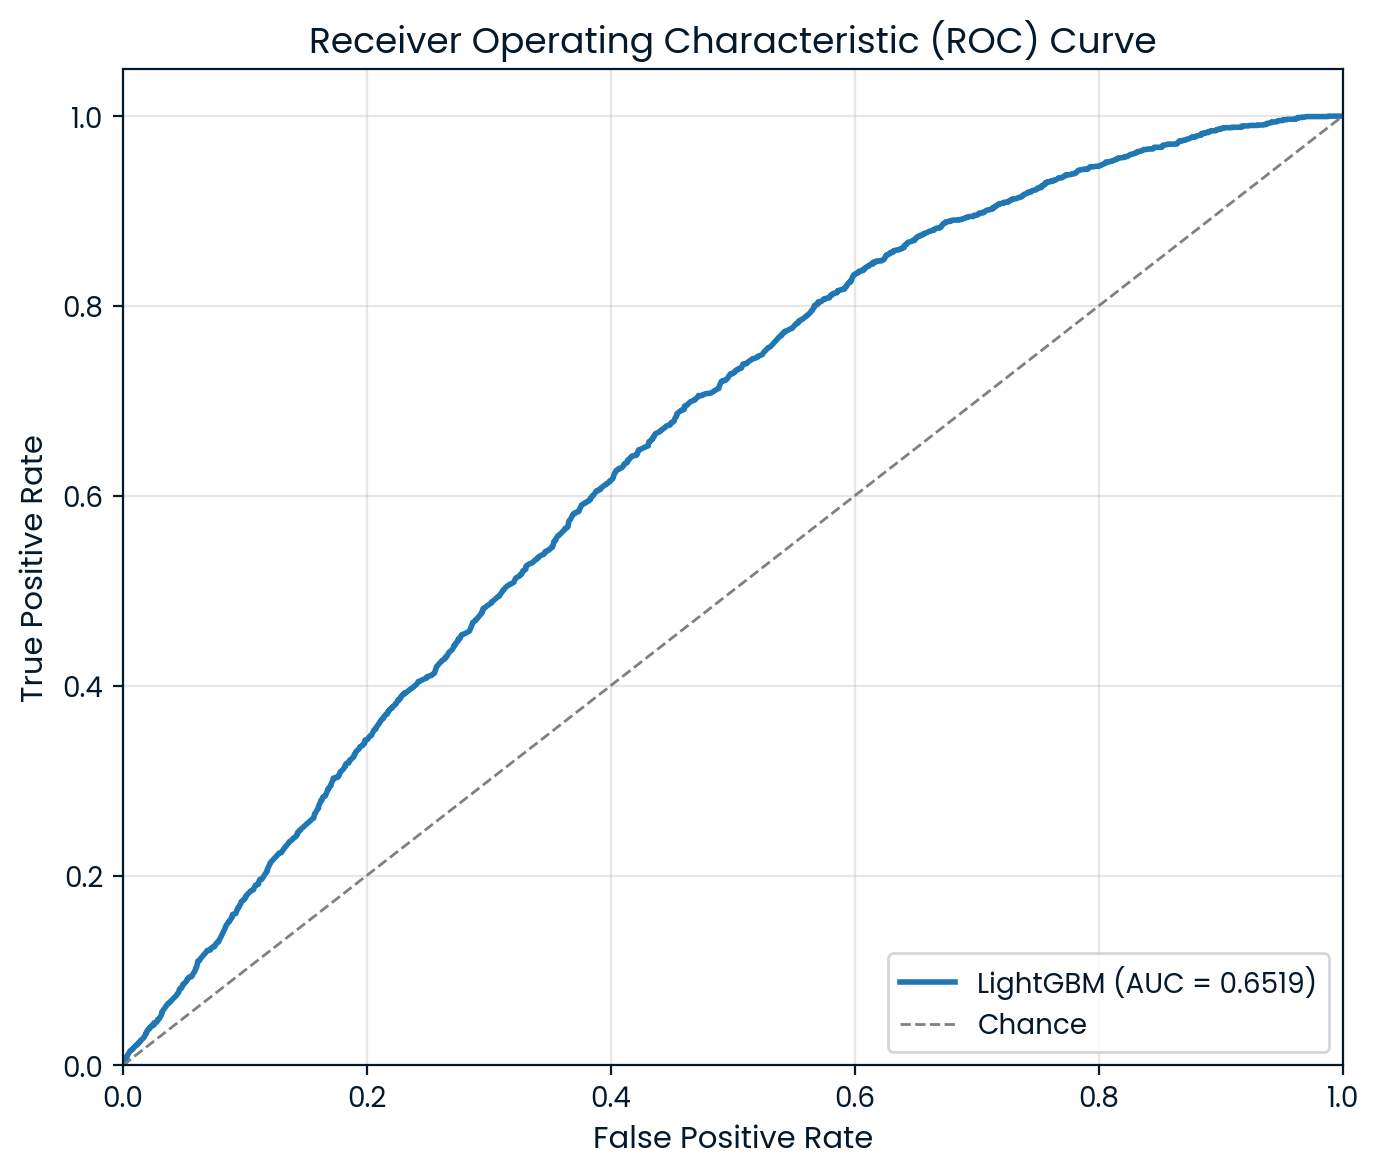

In [3]:
# ============================================================
# Fasciolosis Prediction in Uruguayan Bovine Carcasses
# End-to-End Pipeline:
#   - Data curation and feature derivation
#   - Feature ranking (Random Forest with grouped importances)
#   - Model selection (LightGBM) with Bayesian hyperparameter optimization
#   - Final training and comprehensive evaluation
#   - ROC curve visualization with AUC
#
# Study design notes:
#   - Target: fasciola (binary infection indicator)
#   - Numeric features (primary): age_teeth, carcass_weight, fat_score, carcass_conformation_score
#   - Optional categorical feature: productive_purpose (one-hot encoded; toggle via INCLUDE_CATEGORICALS)
#   - LightGBM logs silenced; early stopping applied in CV via callbacks for version compatibility
#   - Assumes the input DataFrame `df_uruguay` is available in memory
# ============================================================

# Installation:
# !pip install lightgbm bayesian-optimization scikit-learn pandas numpy matplotlib

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

from bayes_opt import BayesianOptimization
import lightgbm as lgb
from lightgbm import LGBMClassifier


# -----------------------------
# Configuration (study constants)
# -----------------------------
INCLUDE_CATEGORICALS = True   # Enable/disable inclusion of 'productive_purpose' via one-hot encoding
TOP_K = 3                     # Number of top (original-level) features retained for modeling
RANDOM_STATE = 42             # Reproducibility seed


# -----------------------------
# Data curation and feature derivation
# -----------------------------
def clean_and_prepare(df: pd.DataFrame) -> pd.DataFrame:
    """
    Standardize column names, correct known typos, and derive temporal features.
    - Normalization: lower-case, trimmed column names.
    - Typo corrections: 'age_teeh' → 'age_teeth'; 'productive_puropose' → 'productive_purpose'.
    - Temporal derivation: 'month' extracted from 'date' when available.
    """
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]

    if "age_teeh" in df.columns and "age_teeth" not in df.columns:
        df = df.rename(columns={"age_teeh": "age_teeth"})
    if "productive_puropose" in df.columns and "productive_purpose" not in df.columns:
        df = df.rename(columns={"productive_puropose": "productive_purpose"})

    if "month" not in df.columns:
        if "date" in df.columns:
            df["date"] = pd.to_datetime(df["date"], errors="coerce")
            df["month"] = df["date"].dt.month
        else:
            df["month"] = np.nan

    return df


def make_ohe() -> OneHotEncoder:
    """
    One-Hot Encoder with version-safe configuration.
    - Newer scikit-learn: use sparse_output=False
    - Older scikit-learn: fallback to sparse=False
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor(numeric_cols, categorical_cols) -> ColumnTransformer:
    """
    Preprocessing architecture:
    - Numeric features: median imputation (robust to skew/outliers).
    - Categorical features: mode imputation + one-hot encoding (unknown categories handled).
    """
    numeric_transformer = SimpleImputer(strategy="median")

    if categorical_cols:
        categorical_transformer = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", make_ohe()),
            ]
        )
        preprocessor = ColumnTransformer(
            transformers=[
                ("num", numeric_transformer, numeric_cols),
                ("cat", categorical_transformer, categorical_cols),
            ],
            remainder="drop",
            verbose_feature_names_out=True,
        )
    else:
        preprocessor = ColumnTransformer(
            transformers=[("num", numeric_transformer, numeric_cols)],
            remainder="drop",
            verbose_feature_names_out=True,
        )
    return preprocessor


# -----------------------------
# Feature ranking (Random Forest with grouped importances)
# -----------------------------
def grouped_feature_importances(rf_pipeline: Pipeline,
                                preprocessor: ColumnTransformer,
                                orig_num_cols,
                                orig_cat_cols) -> pd.DataFrame:
    """
    Aggregate model-based importances (post-preprocessing) to original feature names.
    - Numeric features: direct mapping.
    - Categorical features: sum importances across one-hot components to original variable.
    """
    feature_names = preprocessor.get_feature_names_out()
    importances = rf_pipeline.named_steps["rf"].feature_importances_

    grouped = {}
    for fname, imp in zip(feature_names, importances):
        if fname.startswith("num__"):
            orig = fname.replace("num__", "", 1)
        elif fname.startswith("cat__"):
            remainder = fname.replace("cat__", "", 1)
            orig = None
            for c in orig_cat_cols:
                if remainder == c or remainder.startswith(c + "_"):
                    orig = c
                    break
            if orig is None:
                orig = remainder.split("_")[0]
        else:
            orig = fname
        grouped[orig] = grouped.get(orig, 0.0) + imp

    return (
        pd.DataFrame({"feature": list(grouped.keys()), "importance": list(grouped.values())})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )


def rank_features_with_rf(X_df: pd.DataFrame,
                          y: pd.Series,
                          numeric_cols,
                          categorical_cols,
                          random_state: int = RANDOM_STATE) -> pd.DataFrame:
    """
    Fit a RandomForest within a preprocessing pipeline and compute grouped importances.
    - Imputation and one-hot encoding applied consistently with later modeling steps.
    - Returns a ranked DataFrame of original feature importances.
    """
    preprocessor = build_preprocessor(numeric_cols, categorical_cols)
    rf_pipeline = Pipeline(
        steps=[
            ("prep", preprocessor),
            ("rf", RandomForestClassifier(
                n_estimators=500,
                max_depth=None,
                random_state=random_state,
                n_jobs=-1,
                class_weight="balanced",
            )),
        ]
    )
    rf_pipeline.fit(X_df, y)
    return grouped_feature_importances(
        rf_pipeline,
        rf_pipeline.named_steps["prep"],
        numeric_cols,
        categorical_cols,
    )


# -----------------------------
# Model selection via Bayesian optimization (CV AUC, early stopping)
# -----------------------------
def cv_auc_with_early_stopping_df(X_df: pd.DataFrame,
                                  y: pd.Series,
                                  params: dict,
                                  numeric_cols,
                                  categorical_cols,
                                  n_splits: int = 5,
                                  random_state: int = RANDOM_STATE,
                                  stopping_rounds: int = 50) -> float:
    """
    Cross-validation protocol:
    - Per fold: fit preprocessing on training split (impute + one-hot), transform validation split.
    - Train LightGBM with callbacks-based early stopping; evaluate with ROC AUC.
    - Return mean AUC across folds.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    aucs = []

    for tr_idx, va_idx in skf.split(X_df, y):
        X_tr_df, X_va_df = X_df.iloc[tr_idx], X_df.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        preprocessor = build_preprocessor(numeric_cols, categorical_cols)
        X_tr_imp = preprocessor.fit_transform(X_tr_df)
        X_va_imp = preprocessor.transform(X_va_df)

        clf = LGBMClassifier(**params)
        clf.fit(
            X_tr_imp,
            y_tr,
            eval_set=[(X_va_imp, y_va)],
            eval_metric="auc",
            callbacks=[
                lgb.early_stopping(stopping_rounds=stopping_rounds, verbose=False),
                lgb.log_evaluation(period=0),
            ],
        )

        y_va_proba = clf.predict_proba(X_va_imp)[:, 1]
        aucs.append(roc_auc_score(y_va, y_va_proba))

    return float(np.mean(aucs))


# -----------------------------
# Ingest and baseline preparation
# -----------------------------
df_uruguay = pd.read_excel('data_set_updt.xlsx')
df = clean_and_prepare(df_uruguay)
target_col = "fasciola"
if target_col not in df.columns:
    raise ValueError("Target column 'fasciola' not found.")

# Candidate features (carcass_conformation_score treated as numeric)
if INCLUDE_CATEGORICALS:
    numeric_candidates = ["age_teeth", "carcass_weight", "fat_score", "carcass_conformation_score"]
    categorical_candidates = ["productive_purpose"] if "productive_purpose" in df.columns else []
else:
    numeric_candidates = ["age_teeth", "carcass_weight", "fat_score", "carcass_conformation_score"]
    categorical_candidates = []

present_numeric = [c for c in numeric_candidates if c in df.columns]
present_categorical = [c for c in categorical_candidates if c in df.columns]

use_cols = present_numeric + present_categorical + [target_col]
df_use = df[use_cols].copy()

for c in present_numeric:
    df_use[c] = pd.to_numeric(df_use[c], errors="coerce")

X_full = df_use[present_numeric + present_categorical]
y_full = df_use[target_col].astype(int)

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=RANDOM_STATE, stratify=y_full
)


# -----------------------------
# Feature ranking and top-K selection
# -----------------------------
imp_df = rank_features_with_rf(
    X_train_df,
    y_train,
    numeric_cols=present_numeric,
    categorical_cols=present_categorical,
    random_state=RANDOM_STATE,
)

top_k = min(TOP_K, len(imp_df))
top_features = imp_df["feature"].head(top_k).tolist()

print("\nGrouped feature importances (RandomForest):")
print(imp_df.to_string(index=False))
print(f"\nSelected top-{top_k} features for modeling: {top_features}")

top_numeric = [f for f in top_features if f in present_numeric]
top_categorical = [f for f in top_features if f in present_categorical]

X_train_top = X_train_df[top_numeric + top_categorical].copy()
X_test_top = X_test_df[top_numeric + top_categorical].copy()


# -----------------------------
# Bayesian hyperparameter optimization (maximize CV AUC)
# -----------------------------
def lgb_objective(num_leaves, learning_rate, n_estimators, min_child_samples,
                  subsample, colsample_bytree, reg_lambda, reg_alpha):
    params = {
        "num_leaves": int(round(num_leaves)),
        "learning_rate": float(learning_rate),
        "n_estimators": int(round(n_estimators)),
        "min_child_samples": int(round(min_child_samples)),
        "subsample": max(min(float(subsample), 1.0), 0.5),
        "colsample_bytree": max(min(float(colsample_bytree), 1.0), 0.5),
        "reg_lambda": float(reg_lambda),
        "reg_alpha": float(reg_alpha),
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "objective": "binary",
        "class_weight": "balanced",
        "verbosity": -1,
    }
    return cv_auc_with_early_stopping_df(
        X_df=X_train_top,
        y=y_train,
        params=params,
        numeric_cols=top_numeric,
        categorical_cols=top_categorical,
        n_splits=5,
        random_state=RANDOM_STATE,
        stopping_rounds=50,
    )

pbounds = {
    "num_leaves": (15, 255),
    "learning_rate": (0.005, 0.3),
    "n_estimators": (100, 800),
    "min_child_samples": (5, 100),
    "subsample": (0.5, 1.0),
    "colsample_bytree": (0.5, 1.0),
    "reg_lambda": (0.0, 10.0),
    "reg_alpha": (0.0, 5.0),
}

optimizer = BayesianOptimization(
    f=lgb_objective,
    pbounds=pbounds,
    random_state=RANDOM_STATE,
    verbose=2,
)

optimizer.maximize(init_points=8, n_iter=22)

best_params = optimizer.max["params"]
best_params_cast = {
    "num_leaves": int(round(best_params["num_leaves"])),
    "learning_rate": float(best_params["learning_rate"]),
    "n_estimators": int(round(best_params["n_estimators"])),
    "min_child_samples": int(round(best_params["min_child_samples"])),
    "subsample": float(best_params["subsample"]),
    "colsample_bytree": float(best_params["colsample_bytree"]),
    "reg_lambda": float(best_params["reg_lambda"]),
    "reg_alpha": float(best_params["reg_alpha"]),
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "objective": "binary",
    "class_weight": "balanced",
    "verbosity": -1,
}

print("\nBest hyperparameters (Bayesian Optimization):")
for k, v in best_params_cast.items():
    print(f"  {k}: {v}")


# -----------------------------
# Final training (top-K features; full training split)
# -----------------------------
final_preprocessor = build_preprocessor(top_numeric, top_categorical)
X_train_imp = final_preprocessor.fit_transform(X_train_top)
X_test_imp = final_preprocessor.transform(X_test_top)

final_clf = LGBMClassifier(**best_params_cast)
final_clf.fit(X_train_imp, y_train)


# -----------------------------
# Model evaluation (held-out test set)
# -----------------------------
y_proba = final_clf.predict_proba(X_test_imp)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, zero_division=0)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print("\n=== Test Set Performance ===")
print(f"AUC-ROC       : {auc:.4f}")
print(f"Accuracy      : {acc:.4f}")
print(f"F1-Score      : {f1:.4f}")
print(f"Precision     : {prec:.4f}")
print(f"Recall        : {rec:.4f}")
print("\nConfusion Matrix (TN, FP; FN, TP):")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))


# -----------------------------
# Visualization: ROC curve with AUC
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"LightGBM (AUC = {auc:.4f})", color="tab:blue", lw=2)
plt.plot([0, 1], [0, 1], "--", color="grey", lw=1, label="Chance")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=11)
plt.ylabel("True Positive Rate", fontsize=11)
plt.title("Receiver Operating Characteristic (ROC) Curve", fontsize=13)
plt.grid(alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
